# Designing a Scheduler for a Day in the Life of a Minervan (Part I)

In [46]:
class MaxHeapq:
    """ 
    A class that implements properties and methods 
    that support a max priority queue data structure.

    Attributes
    ----------
    heap : arr
        A Python list where key values in the max heap are stored.
    heap_size: int
        An integer counter of the number of keys present in the max heap.
    """  

    def __init__(self):    
        """
        Initializes an empty heap
        """
        self.heap = []
        self.heap_size = 0

    def left(self, i):
        """
        Returns the index of the left child node from parent node index.
        
        Parameters
        ----------
        i: int
            Index of parent node

        Returns
        ----------
        int
            Index of the left child node
        """
        return 2 * i + 1  #located after all nodes on previous levels + node itself

    def right(self, i):
        """
        Returns the index of the right child node from parent node index.
        
        Parameters
        ----------
        i: int
            Index of parent node

        Returns
        ----------
        int
            Index of the right child node
        """
        return 2 * i + 2  #located immediatly after left child
		
    def parent(self, i):
        """
        Returns the index of the parent node from child node index.
        
        Parameters
        ----------
        i: int
            Index of child node

        Returns
        ----------
        int
            Index of the parent node
        """
        return (i - 1) // 2  #moving up one level; -1 to adjust for 0 indexing

    def maxk(self):     
        """
        Returns the highest key in the priority queue.
        
        Parameters
        ----------
        None

        Returns
        ----------
        int
            The highest key in the priority queue
        """
        if self.heap_size == 0:
            raise ValueError("Heap is empty.")   #error if heap is empty
        return self.heap[0]   #returns root element, which is the max value in maxheap

    def heappush(self, key):  
        """
        Inserts a key into the priority queue.
        
        Parameters
        ----------
        key: int
            The key value to be inserted

        Returns
        ----------
        None
        """
        self.heap.append(-float("inf"))  #temporary value to maintain heap structure
        self.increase_key(self.heap_size, key)  #set the correct value and adjust position
        self.heap_size += 1 

    def increase_key(self, i, key): 
        """
        Modifies the value of a key with a higher value to maintain the max-heap property.
        
        Parameters
        ----------
        i: int
            The index of the key to be modified
        key: int
            The new key value

        Returns
        ----------
        None
        """
        if key < self.heap[i]:
            raise ValueError('New key is smaller than the current key.')
        
        self.heap[i] = key  #set new value
        #while the current index is not the root and the parent's key is less than current key 
        while i > 0 and self.heap[self.parent(i)] < self.heap[i]:  
            j = self.parent(i)  #find parent index of current node
            self.heap[i], self.heap[j] = self.heap[j], self.heap[i]  #swap if parent key is smaller
            i = j  #update i to parent's index
       
    def heapify(self, i):
        """
        Maintains the max-heap property for a subtree rooted at index i.
        
        Parameters
        ----------
        i: int
            The index of the root node of the subtree to be heapified

        Returns
        ----------
        None
        """
        l = self.left(i)
        r = self.right(i)
        largest = i
        
        #find the largest of root, left child, and right child.
        if l < self.heap_size and self.heap[l] > self.heap[i]:   #check left child exists and is larger than current node
            largest = l   #if true, largest is left child
        if r < self.heap_size and self.heap[r] > self.heap[largest]:
            largest = r   #if true, largest is right child
        #if the largest isn't the current node, swap and continue heapifying.
        if largest != i:
            self.heap[i], self.heap[largest] = self.heap[largest], self.heap[i]
            self.heapify(largest)  #recursively heapify subtree rooted at largest index

    def heappop(self):
        """
        Returns and removes the largest key in the max priority queue.
        
        Parameters
        ----------
        None

        Returns
        ----------
        int
            The max value in the heap that is extracted
        """
        if self.heap_size < 1:  #error for empty heap
            raise ValueError('Heap underflow: There are no keys in the priority queue.')
        maxk = self.heap[0]  #max is root 
        
        #move the last element to the root and reduce the heap size
        self.heap[0] = self.heap[-1]
        self.heap.pop()  #remove last element (now duplicate with root)
        self.heap_size -= 1  #decrease heap size
        
        #heapify from the root to maintain max-heap property.
        self.heapify(0)
        return maxk


In [48]:
#Testing: basic insertion and max extraction
#create an instance of MaxHeapq
heap = MaxHeapq()

#insert some elements
heap.heappush(10)
heap.heappush(20)
heap.heappush(5)
heap.heappush(15)

#test max extraction
assert heap.heappop() == 20, "Test Case 1 Failed: Expected max to be 20"
assert heap.heappop() == 15, "Test Case 1 Failed: Expected max to be 15"

print("Test Cases Passed!")


Test Cases Passed!


In [49]:
#Testing: insert duplicates and maintain heap property
#create another instance of MaxHeapq
heap = MaxHeapq()

#insert duplicate values
heap.heappush(30)
heap.heappush(30)

#test max extraction with duplicates
assert heap.heappop() == 30, "Test Case 2 Failed: Expected max to be 30"
assert heap.heappop() == 30, "Test Case 2 Failed: Expected max to be 30"

print("Test Cases Passed!")


Test Cases Passed!


In [67]:
#Testing: handling empty heap 

#extract all elements
heap.heappop()
heap.heappop()

#attempting to pop from an empty heap should raise an error
heap.heappop()

ValueError: Heap underflow: There are no keys in the priority queue.

In [2]:
class Task:
    """
    A class representing a task in the scheduler.

    Attributes
    ----------
    id : int
        Task id (a reference number)
    description : str
        Task short description
    duration : int
        Task duration in minutes
    dependencies : list
        List of task ids that need to precede this task
    status : str
        Current status of the task
    fixed_time : int or None
        The specific time the task should start, in minutes from the start of the day (or None if no fixed time)
    task_deadline : int
        The deadline by which the task should be completed
    importance : str
        The importance level of the task, can be "critical", "moderate", or "low"
    """
    
    #initializes an instance of Task
    def __init__(self, id, description, duration, dependencies, status="N", 
                 fixed_time=None, task_deadline=None, importance="N"):
        self.id = id
        self.description = description
        self.duration = duration
        self.dependencies = dependencies
        self.status = status
        self.fixed_time = fixed_time  #specific time (in minutes) the task should start
        self.task_deadline = task_deadline  #deadline for task completion
        self.importance = importance  #importance level of the task

    def __lt__(self, other):
        #compare tasks based on duration for sorting
        return self.duration < other.duration

In [3]:
#A lot of print statements
#It was used for debugging
#Below there is a cleaner version 

class TaskScheduler:
    """
    A daily task scheduler using custom max heap queue
    """
    NOT_STARTED = 'N'
    IN_PRIORITY_QUEUE = 'I'
    COMPLETED = 'C'
    
    def __init__(self, tasks):
        self.tasks = tasks
        self.priority_queue = MaxHeapq()  #using custom max-heap
        self.task_map = {}  #dictionary to map priority values to tasks

    def print_self(self):
        """
        Prints the details of all tasks added to the scheduler
        """
        print("Tasks added to the scheduler:")
        print("--------------------------------------")
        for t in self.tasks:
            print(f"➡️ '{t.description}', duration = {t.duration} mins, fixed_time={t.fixed_time}, deadline={t.task_deadline}, importance={t.importance}")   
            if len(t.dependencies) > 0:
                print(f"\t ⚠️ This task depends on others!")     
            
    def remove_dependency(self, completed_task_id):
        """
        Removes the dependency from all tasks once a specific task is completed.
    
        Parameters
        ----------
        completed_task_id : int
            The ID of the task that has been completed
        """
        for task in self.tasks:   #iterate over all tasks
            if completed_task_id in task.dependencies:
                task.dependencies.remove(completed_task_id)  #remove completed task from the dependencies lists
                print(f"Dependency on task {completed_task_id} removed for '{task.description}'")          

    def get_tasks_ready(self, current_time):
        """
        Check and add tasks that are ready to the priority queue

        Parameters
        ----------
        current_time : int
            The current time in minutes from the start of the day
        """
        for task in self.tasks:
            if task.status == self.NOT_STARTED:
                if not task.dependencies:   #check tasks that have no dependencies or all dependencies are completed
                    print(f"Checking task: {task.description} at time {self.format_time(current_time)}")
                    if task.fixed_time is None or task.fixed_time == current_time:  #a task with fixed time will only be added if that time is now
                        if task.status != self.IN_PRIORITY_QUEUE:   #prevents adding tasks multiple times (duplicates)
                            priority = self.calculate_priority(task, current_time)  #calculate priority value for task
                            self.priority_queue.heappush(priority)  #add to priority queue
                            self.task_map[priority] = task
                            task.status = self.IN_PRIORITY_QUEUE  #update task status
                            print(f"Added '{task.description}' to priority queue with priority {priority}")
                    else:
                        print(f"Task '{task.description}' has a fixed time at {self.format_time(task.fixed_time)} and will wait until then.")
                elif task.dependencies:
                    print(f"Task '{task.description}' is waiting on dependencies: {task.dependencies}")


    def calculate_priority(self, task, current_time):
        """
        Calculates priority based on task attributes.
        
        Parameters
        ----------
        task : Task
            The task for which to calculate priority
        current_time : int
            The current time in minutes from the start of the day

        Returns
        ----------
        int
            The priority score for the task
        """
        #calculate urgency level based on time remaining until the deadline and how many times that task could be completed until then
        if task.task_deadline is not None:
            urgency = (current_time - task.task_deadline) / task.duration
            urgency_score = 50 if urgency <= 2 else (25 if urgency <= 6 else 0)
        else:
            urgency_score = 0  #no deadline means no urgency

        #calculate importance score based on task importance
        importance_score = {"critical": 40, "moderate": 20, "low": 5}.get(task.importance, 10)

        #duration penalty (longer tasks are deprioritized)
        duration_penalty = task.duration / 2

        #dependency penalty (tasks with more dependencies are deprioritized)
        dependency_penalty = len(task.dependencies) * 10

        #if task has fixed_time it should be prioritized, so that it's at the top of priority queue when scheduled time arrives
        boost_scheduled_tasks = 1000 if task.fixed_time is not None else 0

        #final priority calculation
        priority = importance_score + urgency_score - duration_penalty - dependency_penalty + boost_scheduled_tasks
        return priority 

    def check_unscheduled_tasks(self):
        """
        Checks if there are any tasks that haven't yet been scheduled

        Returns
        ----------
        bool
            True if there are unscheduled tasks, otherwise False
        """
        for task in self.tasks:
            if task.status == self.NOT_STARTED:
                return True
        return False   
    
    def format_time(self, time):
        """
        Formats the time in minutes into a readable format (e.g. 9h30)

        Parameters
        ----------
        time : int
            The time in minutes to format

        Returns
        ---------
        str
            The formatted time as a string
        """
        return f"{time//60}h{time%60:02d}"  #finds hours dividing by 60, and the minutes are the remainder
    
    def run_task_scheduler(self, starting_time):
        """
        Runs the task scheduler starting from given time

        Parameters
        ----------
        starting_time : int
            The starting time in minutes from the start of the day
        """
        current_time = starting_time    #set current time to starting time
        print("Running the scheduler:\n")

        while self.check_unscheduled_tasks() or self.priority_queue.heap_size > 0:   #while there are tasks that haven't been started or queue is not empty
            print(f"Current time: {self.format_time(current_time)}")  #debug: Show the current time
    
            #find tasks that are ready to be scheduled
            self.get_tasks_ready(current_time)
    
            #check if there's a fixed-time task that should start now
            fixed_time_task = None
            for task in self.tasks:
                if task.status == self.IN_PRIORITY_QUEUE and task.fixed_time == current_time:
                    fixed_time_task = task
                    break  #stop searching once we find the task
    
            if fixed_time_task:
                #execute the fixed-time task immediately
                print(f"🕰 t={self.format_time(current_time)}")
                print(f"\tstarted '{fixed_time_task.description}' (fixed time) for {fixed_time_task.duration} mins, with priority {priority}")
                current_time += fixed_time_task.duration  #advance current time by the task's duration
                print(f"\t✅ t={self.format_time(current_time)}, task completed!")
                self.remove_dependency(fixed_time_task.id)   #update dependencies after completion
                fixed_time_task.status = self.COMPLETED   #update status to COMPLETED
                self.get_tasks_ready(current_time)  #re-evaluate tasks since a dependency has been completed
                continue
    
            #find the next fixed-time task that hasn't started yet and is scheduled soon
            next_fixed_time_task = None
            for task in self.tasks:
                if task.fixed_time and task.status == self.NOT_STARTED and task.fixed_time > current_time:
                    if next_fixed_time_task is None or task.fixed_time < next_fixed_time_task.fixed_time: #ensure this is the earliest fixed_task after current time
                        next_fixed_time_task = task
    
            #calculate time until the next fixed-time task, if any
            time_until_fixed = next_fixed_time_task.fixed_time - current_time if next_fixed_time_task else float("inf")
    
            if self.priority_queue.heap_size > 0:
                priority = self.priority_queue.heappop()   #get the highest priority task from the queue
                task = self.task_map.pop(priority)
    
                if task.status == self.COMPLETED:    #skip if the task is already completed
                    continue
    
                if task.duration > time_until_fixed and next_fixed_time_task:   #check if the task an be completed before the next fixed-time task
                    #if the task can't fit, reinsert it and wait until the next fixed-time task
                    print(f"Waiting for next fixed-time task at {self.format_time(next_fixed_time_task.fixed_time)}")
                    self.priority_queue.heappush(priority)  #reinsert the task into the heap
                    self.task_map[priority] = task
                    current_time = next_fixed_time_task.fixed_time
                    continue
    
                #execute the task
                print(f"🕰 t={self.format_time(current_time)}")
                print(f"\tstarted '{task.description}' for {task.duration} mins, with priority {priority}")
                current_time += task.duration
                print(f"\t✅ t={self.format_time(current_time)}, task completed!")
                task.status = self.COMPLETED  #update status to COMPLETED
                self.remove_dependency(task.id)
                self.get_tasks_ready(current_time)  #re-evaluate tasks after a dependency has been completed
    
            else:
                #if no tasks are ready, increment time by 5 minutes and try again
                if time_until_fixed == float("inf"):
                    print("No more tasks to schedule; finishing.")  # Debug
                    break  #exit the loop if there are no more tasks to schedule
                print("No tasks ready; moving to next fixed time.")  # Debug
                current_time += 5  #increment time by 5 minutes
    
        total_time = current_time - starting_time
        print(f"\n🏁 Completed all planned tasks in {total_time//60}h{total_time%60:02d}min!")




In [4]:
my_tasks = [ 
    Task(0, "Wake up and get out of bed", 15, [], importance="critical", task_deadline=570), 
    Task(1, "Go outside", 20, [0], importance="moderate", task_deadline=900), 
    Task(2, "Grab coffee", 20, [0, 1], importance="moderate", task_deadline=940), 
    Task(3, "Take CS110 class", 90, [0], fixed_time=10*60, importance="critical", task_deadline=690), 
    Task(4, "After Class Break", 30, [0, 3], fixed_time=690, importance="low", task_deadline=720), 
    Task(5, "Ride YouBike", 15, [0, 3], importance="low"), 
    Task(6, "Grab lunch at a local restaurant", 40, [0, 5], importance="moderate", task_deadline=810), 
    Task(7, "Get Boba", 10, [0, 5, 6], importance="low", task_deadline=17*60),
    Task(8, "Complete CS111 PCW", 90, [0,6], importance="critical", task_deadline=23*60)
]

simple_scheduler = TaskScheduler(my_tasks) 
simple_scheduler.run_task_scheduler(starting_time=8*60+30)

Running the scheduler:

Current time: 8h30
Checking task: Wake up and get out of bed at time 8h30
Added 'Wake up and get out of bed' to priority queue with priority 82.5
Task 'Go outside' is waiting on dependencies: [0]
Task 'Grab coffee' is waiting on dependencies: [0, 1]
Task 'Take CS110 class' is waiting on dependencies: [0]
Task 'After Class Break' is waiting on dependencies: [0, 3]
Task 'Ride YouBike' is waiting on dependencies: [0, 3]
Task 'Grab lunch at a local restaurant' is waiting on dependencies: [0, 5]
Task 'Get Boba' is waiting on dependencies: [0, 5, 6]
Task 'Complete CS111 PCW' is waiting on dependencies: [0, 6]
🕰 t=8h30
	started 'Wake up and get out of bed' for 15 mins, with priority 82.5
	✅ t=8h45, task completed!
Dependency on task 0 removed for 'Go outside'
Dependency on task 0 removed for 'Grab coffee'
Dependency on task 0 removed for 'Take CS110 class'
Dependency on task 0 removed for 'After Class Break'
Dependency on task 0 removed for 'Ride YouBike'
Dependency on

In [93]:
import random

class TaskScheduler:
    """
    A daily task scheduler using custom max heap queue
    """
    NOT_STARTED = 'N'
    IN_PRIORITY_QUEUE = 'I'
    COMPLETED = 'C'
    
    def __init__(self, tasks):
        self.tasks = tasks
        self.priority_queue = MaxHeapq()  #using custom max-heap
        self.task_map = {}  #dictionary to map priority values to tasks

    def print_self(self):
        """
        Prints the details of all tasks added to the scheduler
        """
        print("Tasks added to the scheduler:")
        print("--------------------------------------")
        for t in self.tasks:
            print(f"➡️ '{t.description}', duration = {t.duration} mins, fixed_time={t.fixed_time}, deadline={t.task_deadline}, importance={t.importance}")   
            if len(t.dependencies) > 0:
                print(f"\t ⚠️ This task depends on others!")     
            
    def remove_dependency(self, completed_task_id):
        """
        Removes the dependency from all tasks once a specific task is completed.
    
        Parameters
        ----------
        completed_task_id : int
            The ID of the task that has been completed
        """
        for task in self.tasks:   #iterate over all tasks
            if completed_task_id in task.dependencies:
                task.dependencies.remove(completed_task_id)  #remove completed task from the dependencies lists
                
    def get_tasks_ready(self, current_time):
        """
        Check and add tasks that are ready to the priority queue

        Parameters
        ----------
        current_time : int
            The current time in minutes from the start of the day
        """
        for task in self.tasks:
            if task.status == self.NOT_STARTED and not task.dependencies:   #check tasks that have no dependencies or all dependencies are completed
                    if task.fixed_time is None or task.fixed_time <= current_time:  #a task with fixed time will only be added if that time is now
                        if task.status != self.IN_PRIORITY_QUEUE:   #prevents adding tasks multiple times (duplicates)
                            priority = self.calculate_priority(task, current_time)  #calculate priority value for task
                            self.priority_queue.heappush(priority)  #add to priority queue
                            self.task_map[priority] = task
                            task.status = self.IN_PRIORITY_QUEUE  #update task status

    def calculate_priority(self, task, current_time):
        """
        Calculates priority based on task attributes.
        
        Parameters
        ----------
        task : Task
            The task for which to calculate priority
        current_time : int
            The current time in minutes from the start of the day

        Returns
        ----------
        int
            The priority score for the task
        """
        #calculate urgency level based on time remaining until the deadline and how many times that task could be completed until then
        if task.task_deadline is not None:
            urgency = (current_time - task.task_deadline) / task.duration
            urgency_score = 50 if urgency <= 2 else (25 if urgency <= 6 else 0)
        else:
            urgency_score = 0  #no deadline means no urgency

        #calculate importance score based on task importance
        importance_score = {"critical": 40, "moderate": 20, "low": 5}.get(task.importance, 10)

        #duration penalty (longer tasks are deprioritized)
        duration_penalty = task.duration / 2

        #dependency penalty (tasks with more dependencies are deprioritized)
        dependency_penalty = len(task.dependencies) * 10

        #final priority calculation
        priority = importance_score + urgency_score - duration_penalty - dependency_penalty

        #add a small random noise to ensure uniqueness
        noise = random.uniform(0, 0.01)
        
        return round(priority + noise, 4)

    def check_unscheduled_tasks(self):
        """
        Checks if there are any tasks that haven't yet been scheduled

        Returns
        ----------
        bool
            True if there are unscheduled tasks, otherwise False
        """
        for task in self.tasks:
            if task.status == self.NOT_STARTED:
                return True
        return False   
    
    def format_time(self, time):
        """
        Formats the time in minutes into a readable format (e.g. 9h30)

        Parameters
        ----------
        time : int
            The time in minutes to format

        Returns
        ---------
        str
            The formatted time as a string
        """
        return f"{time//60}h{time%60:02d}"  #finds hours dividing by 60, and the minutes are the remainder
    
    def run_task_scheduler(self, starting_time):
        """
        Runs the task scheduler starting from given time

        Parameters
        ----------
        starting_time : int
            The starting time in minutes from the start of the day
        """
        current_time = starting_time   #set current time to starting time
        print("Running the scheduler:\n")
        utility_value = 0

        while self.check_unscheduled_tasks() or self.priority_queue.heap_size > 0:   #while there are tasks that haven't been started or queue is not empty
    
            #find tasks that are ready to be scheduled
            self.get_tasks_ready(current_time)

            #find the next fixed-time task that hasn't started yet and is scheduled soon
            next_fixed_time_task = None
            for task in self.tasks:
                if task.fixed_time and task.status == self.NOT_STARTED and task.fixed_time > current_time:
                    if next_fixed_time_task is None or task.fixed_time < next_fixed_time_task.fixed_time: #ensure this is the earliest fixed_task after current time
                        next_fixed_time_task = task
            #calculate time until the next fixed-time task, if any
            time_until_fixed = next_fixed_time_task.fixed_time - current_time if next_fixed_time_task else float("inf")
    
            if self.priority_queue.heap_size > 0:
                priority = self.priority_queue.heappop()  #get the highest priority task from the queue
                task = self.task_map.pop(priority)

                if task.duration > time_until_fixed and next_fixed_time_task: #check if the task an be completed before the next fixed-time task
                    #if the task can't fit, reinsert it and wait until the next fixed-time task
                    self.priority_queue.heappush(priority)  #reinsert the task into the heap
                    self.task_map[priority] = task
                    current_time = next_fixed_time_task.fixed_time
                    continue
    
                #execute the task
                print(f"🕰 t={self.format_time(current_time)}")
                print(f"\tstarted '{task.description}' for {task.duration} mins, with priority {priority}")
                utility_value += priority
                current_time += task.duration
                print(f"\t✅ t={self.format_time(current_time)}, task completed!")
                task.status = self.COMPLETED  #update status to COMPLETED
                self.remove_dependency(task.id)
                self.get_tasks_ready(current_time)  #re-evaluate tasks after a dependency has been completed
    
            else:
                #if no tasks are ready, increment time by 5 minutes and try again
                current_time += 5  #increment time by 5 minutes
    
        total_time = current_time - starting_time
        print(f"\n🏁 Completed all planned tasks in {total_time//60}h{total_time%60:02d}min, and a total utility value of {round(utility_value, 4)}!")

In [64]:
my_tasks = [ 
    Task(0, "Wake up and get out of bed", 15, [], importance="critical", task_deadline=570), 
    Task(1, "Go outside", 20, [0], importance="moderate", task_deadline=900), 
    Task(2, "Grab coffee", 20, [0, 1], importance="moderate", task_deadline=940), 
    Task(3, "Take CS110 class", 90, [0], fixed_time=10*60, importance="critical", task_deadline=690), 
    Task(4, "After Class Break", 30, [0, 3], fixed_time=690, importance="low", task_deadline=720), 
    Task(5, "Ride YouBike", 15, [0, 3], importance="low"), 
    Task(6, "Grab lunch at a local restaurant", 40, [0, 5], importance="moderate", task_deadline=810), 
    Task(7, "Get Boba", 10, [0, 5, 6], importance="low", task_deadline=17*60),
    Task(8, "Complete CS111 PCW", 90, [0,6], importance="critical", task_deadline=23*60)
]

simple_scheduler = TaskScheduler(my_tasks) 
simple_scheduler.run_task_scheduler(starting_time=8*60+30)

Running the scheduler:

🕰 t=8h30
	started 'Wake up and get out of bed' for 15 mins, with priority 82.5004
	✅ t=8h45, task completed!
🕰 t=8h45
	started 'Go outside' for 20 mins, with priority 60.0021
	✅ t=9h05, task completed!
🕰 t=9h05
	started 'Grab coffee' for 20 mins, with priority 60.0023
	✅ t=9h25, task completed!
🕰 t=10h00
	started 'Take CS110 class' for 90 mins, with priority 45.0025
	✅ t=11h30, task completed!
🕰 t=11h30
	started 'After Class Break' for 30 mins, with priority 40.0049
	✅ t=12h00, task completed!
🕰 t=12h00
	started 'Ride YouBike' for 15 mins, with priority -2.4935
	✅ t=12h15, task completed!
🕰 t=12h15
	started 'Grab lunch at a local restaurant' for 40 mins, with priority 50.0061
	✅ t=12h55, task completed!
🕰 t=12h55
	started 'Get Boba' for 10 mins, with priority 50.0024
	✅ t=13h05, task completed!
🕰 t=13h05
	started 'Complete CS111 PCW' for 90 mins, with priority 45.0073
	✅ t=14h35, task completed!

🏁 Completed all planned tasks in 6h05min, and a total utility valu

In [41]:
#Example for pririotizing based on priority value
task_1 = Task(0, "Task 1 - High Priority", 10, [], importance="critical", task_deadline=600)  #high priority task
task_2 = Task(1, "Task 2 - Moderate Priority", 20, [], importance="moderate", task_deadline=900)  #moderate priority task
task_3 = Task(2, "Task 3 - Low Priority", 30, [], importance="low", task_deadline=1200)  #low priority task

scheduler = TaskScheduler([task_1, task_2, task_3])
scheduler.run_task_scheduler(starting_time=8 * 60) #starting at 8am

Running the scheduler:

🕰 t=8h00
	started 'Task 1 - High Priority' for 10 mins, with priority 85.0095
	✅ t=8h10, task completed!
🕰 t=8h10
	started 'Task 2 - Moderate Priority' for 20 mins, with priority 60.0003
	✅ t=8h30, task completed!
🕰 t=8h30
	started 'Task 3 - Low Priority' for 30 mins, with priority 40.0026
	✅ t=9h00, task completed!

🏁 Completed all planned tasks in 1h00min, and a total utility value of 185.0124!


In [65]:
#Example changing order of input
task_4 = Task(3, "Task 1 - High Priority", 10, [], importance="critical", task_deadline=600)  
task_5 = Task(4, "Task 2 - Moderate Priority", 20, [], importance="moderate", task_deadline=900)  
task_6 = Task(5, "Task 3 - Low Priority", 30, [], importance="low", task_deadline=1200) 

#scheduler with the same tasks in different order
scheduler_reordered = TaskScheduler([task_6, task_4, task_5])
scheduler_reordered.run_task_scheduler(starting_time=8 * 60)

#assert statements to confirm that the output order remains the same
assert scheduler.tasks[0].description == scheduler_reordered.tasks[1].description, "First task should be the high priority task"
assert scheduler.tasks[1].description == scheduler_reordered.tasks[2].description, "Second task should be the moderate priority task"
assert scheduler.tasks[2].description == scheduler_reordered.tasks[0].description, "Third task should be the low priority task"

Running the scheduler:

🕰 t=8h00
	started 'Task 1 - High Priority' for 10 mins, with priority 85.0096
	✅ t=8h10, task completed!
🕰 t=8h10
	started 'Task 2 - Moderate Priority' for 20 mins, with priority 60.006
	✅ t=8h30, task completed!
🕰 t=8h30
	started 'Task 3 - Low Priority' for 30 mins, with priority 40.0078
	✅ t=9h00, task completed!

🏁 Completed all planned tasks in 1h00min, and a total utility value of 185.0234!


In [69]:
#ADD TASK 
#direspecting deadlines

my_tasks_1 = [ 
    Task(0, "Wake up and get out of bed", 15, [], importance="critical", task_deadline=570), 
    Task(1, "Go outside", 20, [0], importance="moderate", task_deadline=900), 
    Task(2, "Grab coffee", 20, [0, 1], importance="moderate", task_deadline=940), 
    Task(3, "Take CS110 class", 90, [0], fixed_time=10*60, importance="critical", task_deadline=690), 
    Task(4, "After Class Break", 30, [0, 3], fixed_time=690, importance="low", task_deadline=720), 
    Task(5, "Ride YouBike", 15, [0, 3], importance="low"), 
    Task(6, "Grab lunch at a local restaurant", 40, [0, 5], importance="moderate", task_deadline=810), 
    Task(7, "Get Boba", 10, [0, 5, 6], importance="low", task_deadline=17*60),
    Task(8, "Complete CS111 PCW", 90, [0,6], importance="critical", task_deadline=23*60),
    Task(9, "Swimming", 90, [0], importance="moderate", task_deadline=17*60)
]

simple_scheduler = TaskScheduler(my_tasks_1) 
simple_scheduler.run_task_scheduler(starting_time=8*60)

Running the scheduler:

🕰 t=8h00
	started 'Wake up and get out of bed' for 15 mins, with priority 82.5091
	✅ t=8h15, task completed!
🕰 t=8h15
	started 'Go outside' for 20 mins, with priority 60.0018
	✅ t=8h35, task completed!
🕰 t=8h35
	started 'Grab coffee' for 20 mins, with priority 60.0091
	✅ t=8h55, task completed!
🕰 t=10h00
	started 'Take CS110 class' for 90 mins, with priority 45.0056
	✅ t=11h30, task completed!
🕰 t=11h30
	started 'After Class Break' for 30 mins, with priority 40.0082
	✅ t=12h00, task completed!
🕰 t=12h00
	started 'Swimming' for 90 mins, with priority 25.0091
	✅ t=13h30, task completed!
🕰 t=13h30
	started 'Ride YouBike' for 15 mins, with priority -2.4982
	✅ t=13h45, task completed!
🕰 t=13h45
	started 'Grab lunch at a local restaurant' for 40 mins, with priority 50.0033
	✅ t=14h25, task completed!
🕰 t=14h25
	started 'Get Boba' for 10 mins, with priority 50.0053
	✅ t=14h35, task completed!
🕰 t=14h35
	started 'Complete CS111 PCW' for 90 mins, with priority 45.0095
	✅

Running the scheduler:

🕰 t=8h00
	started 'Task 7' for 47 mins, with priority 46.5065
	✅ t=8h47, task completed!
🕰 t=8h47
	started 'Task 1' for 25 mins, with priority 27.5026
	✅ t=9h12, task completed!
🕰 t=11h57
	started 'Task 6' for 28 mins, with priority -8.996
	✅ t=12h25, task completed!
🕰 t=17h30
	started 'Task 0' for 54 mins, with priority 3.0093
	✅ t=18h24, task completed!
🕰 t=18h24
	started 'Task 2' for 41 mins, with priority 19.5009
	✅ t=19h05, task completed!
🕰 t=19h05
	started 'Task 3' for 53 mins, with priority -21.4992
	✅ t=19h58, task completed!
🕰 t=19h58
	started 'Task 4' for 56 mins, with priority 12.0062
	✅ t=20h54, task completed!
🕰 t=20h54
	started 'Task 9' for 58 mins, with priority 36.0082
	✅ t=21h52, task completed!
🕰 t=21h52
	started 'Task 5' for 5 mins, with priority 2.5015
	✅ t=21h57, task completed!
🕰 t=21h57
	started 'Task 8' for 43 mins, with priority -1.4985
	✅ t=22h40, task completed!

🏁 Completed all planned tasks in 14h40min, and a total utility value of 

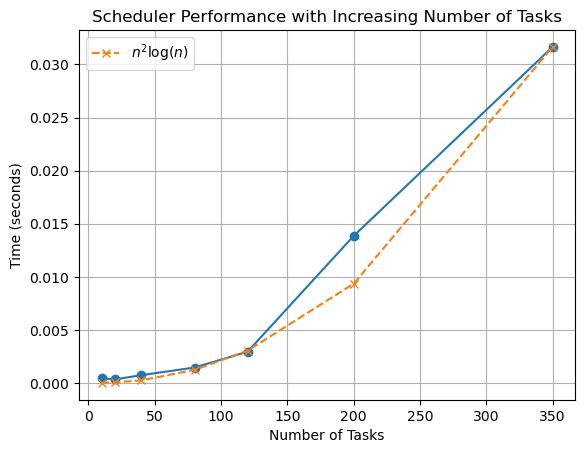

In [92]:
import time
import matplotlib.pyplot as plt
import numpy as np
import math

#sample Task class (simplified for testing purposes)
class Task:
    def __init__(self, task_id, description, duration, dependencies=None, fixed_time=None, importance="low", task_deadline=None):
        self.id = task_id
        self.description = description
        self.duration = duration
        self.dependencies = dependencies or []
        self.fixed_time = fixed_time
        self.importance = importance
        self.task_deadline = task_deadline
        self.status = TaskScheduler.NOT_STARTED

#function to generate random tasks for testing
def generate_tasks(num_tasks):
    tasks = []
    for i in range(num_tasks):
        duration = random.randint(5, 60)  #random duration between 5 and 60 mins
        dependencies = random.sample(range(max(0, i - 5), i), k=random.randint(0, min(3, i)))  #random dependencies within recent tasks
        fixed_time = random.choice([None, random.randint(8*60, 23*60)])  #random fixed time or None
        importance = random.choice(["low", "moderate", "critical"])
        task_deadline = random.choice([None, random.randint(9*60, 23*60)])  #random deadline or None
        tasks.append(Task(i, f"Task {i}", duration, dependencies, fixed_time, importance, task_deadline))
    return tasks

#running experiments
task_counts = [10, 20, 40, 80, 120, 200, 350]
times = []
theoretical_times = [] #check if it matches with theoretical time complexity

for num_tasks in task_counts:
    tasks = generate_tasks(num_tasks)
    scheduler = TaskScheduler(tasks)
    start_time = time.time()
    scheduler.run_task_scheduler(starting_time=8 * 60)  # start at 8:00 AM
    end_time = time.time()
    times.append(end_time - start_time)
    theoretical_time = num_tasks ** 2 * math.log(num_tasks + 1)  #+1 to avoid log(0)
    theoretical_times.append(theoretical_time)
    print(f"Completed scheduling for {num_tasks} tasks in {end_time - start_time:.4f} seconds.")

max_time = max(times) #uses actual max runtime as scaling reference
max_theoretical_time = max(theoretical_times) #max in theoretical times
normalized_theoretical_times = [t * (max_time / max_theoretical_time) for t in theoretical_times] #scales theoretical times proportionally to match the scale of the experimental times

#plotting results
plt.plot(task_counts, times, marker='o')
plt.plot(task_counts, normalized_theoretical_times, marker='x', linestyle='--', label=r"$n^2 \log(n)$")
plt.xlabel("Number of Tasks")
plt.ylabel("Time (seconds)")
plt.title("Scheduler Performance with Increasing Number of Tasks")
plt.grid(True)
plt.legend()
plt.show()
